# Notebook 07 — Comparativo Final: Baseline vs. Modelos com Sentimento (H=1)

> **Pré-requisito:** executar o Notebook 02 e o Notebook 06 até as células de exportação, gerando os arquivos:
> - `resultados_sem_sentimento.csv`
> - `resultados_com_sentimento.csv`

## Regras metodológicas
- Nenhum modelo é reestimado aqui.
- O critério de comparação principal é o **RMSE** no conjunto de teste (com correção de bias).
- Para os modelos com sentimento, são exibidos os **top 3 por família** (menor RMSE com bias).

## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression

COLOR = "#0e5764"  # padrão visual do Notebook 02

## 2. Leitura dos resultados exportados

In [2]:
# ── Baseline (Notebook 02) ───────────────────────────────────────────────────
df_base = pd.read_csv("resultados_sem_sentimento.csv")

# Padroniza nome da coluna de modelo (pode vir como "Modelo" ou "index")
if "Modelo" not in df_base.columns and "index" in df_base.columns:
    df_base = df_base.rename(columns={"index": "Modelo"})

# Identifica família a partir do nome do modelo
def _familia(nome):
    n = str(nome).upper()
    if "ARIMA" in n: return "ARIMA"
    if "SVR"   in n: return "SVR"
    if "XGBOOST" in n or "XGB" in n: return "XGBoost"
    return "Outro"

df_base["Família"]  = df_base["Modelo"].apply(_familia)
df_base["Com bias"] = df_base["Modelo"].str.contains("bias", case=False, na=False)
df_base["Com bias"] = df_base["Com bias"].map({True: "Sim", False: "Não"})

print(f"Baseline carregado: {df_base.shape[0]} linhas")
display(df_base.round(6))

# ── Sentimento (Notebook 06) ─────────────────────────────────────────────────
df_sent = pd.read_csv("resultados_com_sentimento.csv")

print(f"\nSentimento carregado: {df_sent.shape[0]} linhas")
display(df_sent.round(6))

Baseline carregado: 6 linhas


,Modelo,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept,Ranking RMSE,Família,Com bias
0,"ARIMA(2, 1, 4) (h=1) + bias",0.070517,0.097328,0.912723,0.019726,0.940752,0.183420,1,ARIMA,Sim
1,"ARIMA(2, 1, 4) (h=1)",0.072136,0.099060,0.909589,0.027005,0.940752,0.176141,2,ARIMA,Não
2,"SVR (h=1, k=1) + bias",0.081045,0.108325,0.891885,-0.003964,0.816916,0.631715,3,SVR,Sim
3,"SVR (h=1, k=1)",0.083947,0.115626,0.876821,0.040629,0.816916,0.587122,4,SVR,Não
4,"XGBoost (h=1, k=7) + bias",0.097261,0.120267,0.866734,0.014192,0.789437,0.707775,5,XGBoost,Sim
5,"XGBoost (h=1, k=7)",0.109156,0.139883,0.819717,0.072832,0.789437,0.649135,6,XGBoost,Não



Sentimento carregado: 36 linhas


,Rank,Família,Tipo Relatório,Modelo Sentimento,Série Sentimento,Configuração,Janela Sentimento,Com bias,Bias estimado treino,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept,N,id_predicao
0,3,ARIMAX,Atas do Copom,BERT Multilingual,copom_score_bert,"ARIMA(2, 1, 4)","t, t-1, t-2",Não,NaN,0.067838,0.090813,0.924017,0.015340,0.939685,0.191466,24,ARIMAX|copom_score_bert|sem_bias
1,3,ARIMAX,Atas do Copom,BERT Multilingual,copom_score_bert,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.020629,0.069656,0.089664,0.925927,-0.005289,0.939685,0.212095,24,ARIMAX|copom_score_bert|com_bias
2,1,ARIMAX,Atas do Copom,Mistral,copom_score_mistral,"ARIMA(2, 1, 4)","t, t-1, t-2",Não,NaN,0.063953,0.087210,0.929925,0.018834,0.945532,0.167922,24,ARIMAX|copom_score_mistral|sem_bias
3,1,ARIMAX,Atas do Copom,Mistral,copom_score_mistral,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.021556,0.065200,0.085196,0.933125,-0.002722,0.945532,0.189478,24,ARIMAX|copom_score_mistral|com_bias
4,2,ARIMAX,Atas do Copom,TextBlob,copom_score_textblob,"ARIMA(2, 1, 4)","t, t-1, t-2",Não,NaN,0.070546,0.090270,0.924921,0.024355,0.949129,0.150068,24,ARIMAX|copom_score_textblob|sem_bias
5,2,ARIMAX,Atas do Copom,TextBlob,copom_score_textblob,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.012900,0.069984,0.087674,0.929177,0.011456,0.949129,0.162968,24,ARIMAX|copom_score_textblob|com_bias
6,3,SVR,Atas do Copom,FinBERT-PT-BR,copom_score_finbert,k=1,t,Não,NaN,0.117231,0.166425,0.744809,0.040470,0.732933,0.875237,24,SVR|copom_score_finbert|sem_bias
7,3,SVR,Atas do Copom,FinBERT-PT-BR,copom_score_finbert,k=1,t,Sim,0.020070,0.117031,0.162714,0.756065,0.020399,0.732933,0.895307,24,SVR|copom_score_finbert|com_bias
8,1,SVR,Atas do Copom,Média dos Modelos,copom_score_media,k=1,t,Não,NaN,0.102139,0.130475,0.843151,0.034791,0.819569,0.583862,24,SVR|copom_score_media|sem_bias
9,1,SVR,Atas do Copom,Média dos Modelos,copom_score_media,k=1,t,Sim,0.008470,0.101433,0.128476,0.847920,0.026321,0.819569,0.592332,24,SVR|copom_score_media|com_bias


## 3. Tabela comparativa final

In [8]:
# ── Baseline com bias ────────────────────────────────────────────────────────
base_cb = (
    df_base[df_base["Com bias"] == "Sim"]
    .sort_values("RMSE")
    .reset_index(drop=True)
    .copy()
)

# ── Sentimento com bias ──────────────────────────────────────────────────────
sent_cb = (
    df_sent[df_sent["Com bias"] == "Sim"]
    .sort_values(["Família", "RMSE"])
    .reset_index(drop=True)
    .copy()
)
sent_cb["Rank"] = sent_cb.groupby("Família").cumcount() + 1

# ── ΔRMSE em relação ao baseline da mesma família ────────────────────────────
rmse_baseline = base_cb.set_index("Família")["RMSE"].to_dict()

_familia_para_baseline = {
    "ARIMA":   "ARIMA",
    "ARIMAX":  "ARIMA",
    "SVR":     "SVR",
    "XGBoost": "XGBoost",
}

sent_cb["ΔRMSE vs Baseline"] = sent_cb.apply(
    lambda r: round(r["RMSE"] - rmse_baseline.get(_familia_para_baseline.get(r["Família"], r["Família"]), np.nan), 6), axis=1
)
sent_cb["Melhorou?"] = sent_cb["ΔRMSE vs Baseline"].apply(
    lambda v: "Sim" if v < 0 else "Nao"
)

# ── Monta tabela unificada ───────────────────────────────────────────────────
linhas_base = base_cb[["Família","Modelo","RMSE","MAE","R2",
                         "Bias (obs - prev)","Slope pred~obs"]].copy()
linhas_base.insert(1, "Tipo", "Baseline")
linhas_base.insert(3, "Tipo Relatório",    "—")
linhas_base.insert(4, "Modelo Sentimento", "—")
linhas_base["Rank"]                = "—"
linhas_base["ΔRMSE vs Baseline"]   = np.nan
linhas_base["Melhorou?"]           = "—"

linhas_sent = sent_cb[["Família","Rank","Tipo Relatório","Modelo Sentimento",
                         "Configuração","RMSE","MAE","R2",
                         "Bias (obs - prev)","Slope pred~obs",
                         "ΔRMSE vs Baseline","Melhorou?"]].copy()
linhas_sent.insert(1, "Tipo",  linhas_sent["Rank"].apply(lambda r: f"+ Sentimento #{r}"))
linhas_sent.insert(2, "Modelo", linhas_sent.apply(
    lambda r: f"{r['Família']} + {r['Tipo Relatório']} + {r['Modelo Sentimento']}", axis=1))

COLS_COMP = ["Família","Tipo","Modelo Sentimento","Tipo Relatório",
             "RMSE","MAE","R2","Bias (obs - prev)","Slope pred~obs",
             "ΔRMSE vs Baseline","Melhorou?"]

df_comp = (
    pd.concat([linhas_base[COLS_COMP], linhas_sent[COLS_COMP]], ignore_index=True)
    .sort_values(["Família","RMSE"])
    .reset_index(drop=True)
)

print("=== Comparativo Final — Baseline vs. Sentimento (H=1, com bias) ===")
display(df_comp.round(6))

=== Comparativo Final — Baseline vs. Sentimento (H=1, com bias) ===


,Família,Tipo,Modelo Sentimento,Tipo Relatório,RMSE,MAE,R2,Bias (obs - prev),Slope pred~obs,ΔRMSE vs Baseline,Melhorou?
0,ARIMA,Baseline,—,—,0.097328,0.070517,0.912723,0.019726,0.940752,NaN,—
1,ARIMAX,+ Sentimento #1,Mistral,Atas do Copom,0.085196,0.065200,0.933125,-0.002722,0.945532,-0.012132,Sim
2,ARIMAX,+ Sentimento #2,BERT Multilingual,Relatórios de Estatísticas,0.085941,0.067594,0.931951,0.005082,0.938433,-0.011387,Sim
3,ARIMAX,+ Sentimento #3,TextBlob,Atas do Copom,0.087674,0.069984,0.929177,0.011456,0.949129,-0.009654,Sim
4,ARIMAX,+ Sentimento #4,BERT Multilingual,Atas do Copom,0.089664,0.069656,0.925927,-0.005289,0.939685,-0.007664,Sim
5,ARIMAX,+ Sentimento #5,TextBlob,Relatórios de Estatísticas,0.106412,0.081910,0.895670,-0.011457,0.932257,0.009084,Nao
6,ARIMAX,+ Sentimento #6,FinBERT-PT-BR,Relatórios de Estatísticas,0.108293,0.082048,0.891950,-0.003441,0.968048,0.010965,Nao
7,SVR,Baseline,—,—,0.108325,0.081045,0.891885,-0.003964,0.816916,NaN,—
8,SVR,+ Sentimento #1,Média dos Modelos,Atas do Copom,0.128476,0.101433,0.847920,0.026321,0.819569,0.020151,Nao
9,SVR,+ Sentimento #2,TextBlob,Relatórios de Estatísticas,0.150715,0.117125,0.790714,-0.013323,0.829713,0.042390,Nao


In [12]:
# ── Ranking dos maiores GANHOS (ΔRMSE < 0) ───────────────────────────────────
ganhos = (
    df_comp[df_comp["Melhorou?"] == "Sim"]
    .sort_values("ΔRMSE vs Baseline")
    .reset_index(drop=True)
)
ganhos.index += 1
ganhos.index.name = "Rank"

cols_rank = [
    "Família", "Tipo Relatório", "Modelo Sentimento",
    "RMSE", "MAE", "R2", "ΔRMSE vs Baseline",
]

print(f"=== Modelos que MELHORARAM o baseline — {len(ganhos)} casos ===")
display(ganhos[cols_rank].round(6))

=== Modelos que MELHORARAM o baseline — 4 casos ===


,Família,Tipo Relatório,Modelo Sentimento,RMSE,MAE,R2,ΔRMSE vs Baseline
Rank,,,,,,,
1,ARIMAX,Atas do Copom,Mistral,0.085196,0.065200,0.933125,-0.012132
2,ARIMAX,Relatórios de Estatísticas,BERT Multilingual,0.085941,0.067594,0.931951,-0.011387
3,ARIMAX,Atas do Copom,TextBlob,0.087674,0.069984,0.929177,-0.009654
4,ARIMAX,Atas do Copom,BERT Multilingual,0.089664,0.069656,0.925927,-0.007664


In [13]:
# ── Ranking dos que PIORARAM o baseline (ΔRMSE > 0) ──────────────────────────
pioras = (
    df_comp[df_comp["Melhorou?"] == "Nao"]
    .sort_values("ΔRMSE vs Baseline", ascending=False)
    .reset_index(drop=True)
)
pioras.index += 1
pioras.index.name = "Rank"

print(f"=== Modelos que PIORARAM o baseline — {len(pioras)} casos ===")
display(pioras[cols_rank].round(6))

=== Modelos que PIORARAM o baseline — 14 casos ===


,Família,Tipo Relatório,Modelo Sentimento,RMSE,MAE,R2,ΔRMSE vs Baseline
Rank,,,,,,,
1,SVR,Atas do Copom,FinBERT-PT-BR,0.162714,0.117031,0.756065,0.054389
2,SVR,Relatórios de Estatísticas,BERT Multilingual,0.161158,0.122791,0.760708,0.052833
3,SVR,Relatórios de Estatísticas,NLTK/VADER,0.154584,0.119932,0.779830,0.046259
4,SVR,Atas do Copom,Mistral,0.153328,0.121994,0.783394,0.045003
5,SVR,Relatórios de Estatísticas,TextBlob,0.150715,0.117125,0.790714,0.042390
6,SVR,Atas do Copom,Média dos Modelos,0.128476,0.101433,0.847920,0.020151
7,ARIMAX,Relatórios de Estatísticas,FinBERT-PT-BR,0.108293,0.082048,0.891950,0.010965
8,ARIMAX,Relatórios de Estatísticas,TextBlob,0.106412,0.081910,0.895670,0.009084
9,XGBoost,Atas do Copom,Média dos Modelos,0.126741,0.107061,0.852001,0.006474


## 4. Gráfico comparativo de RMSE

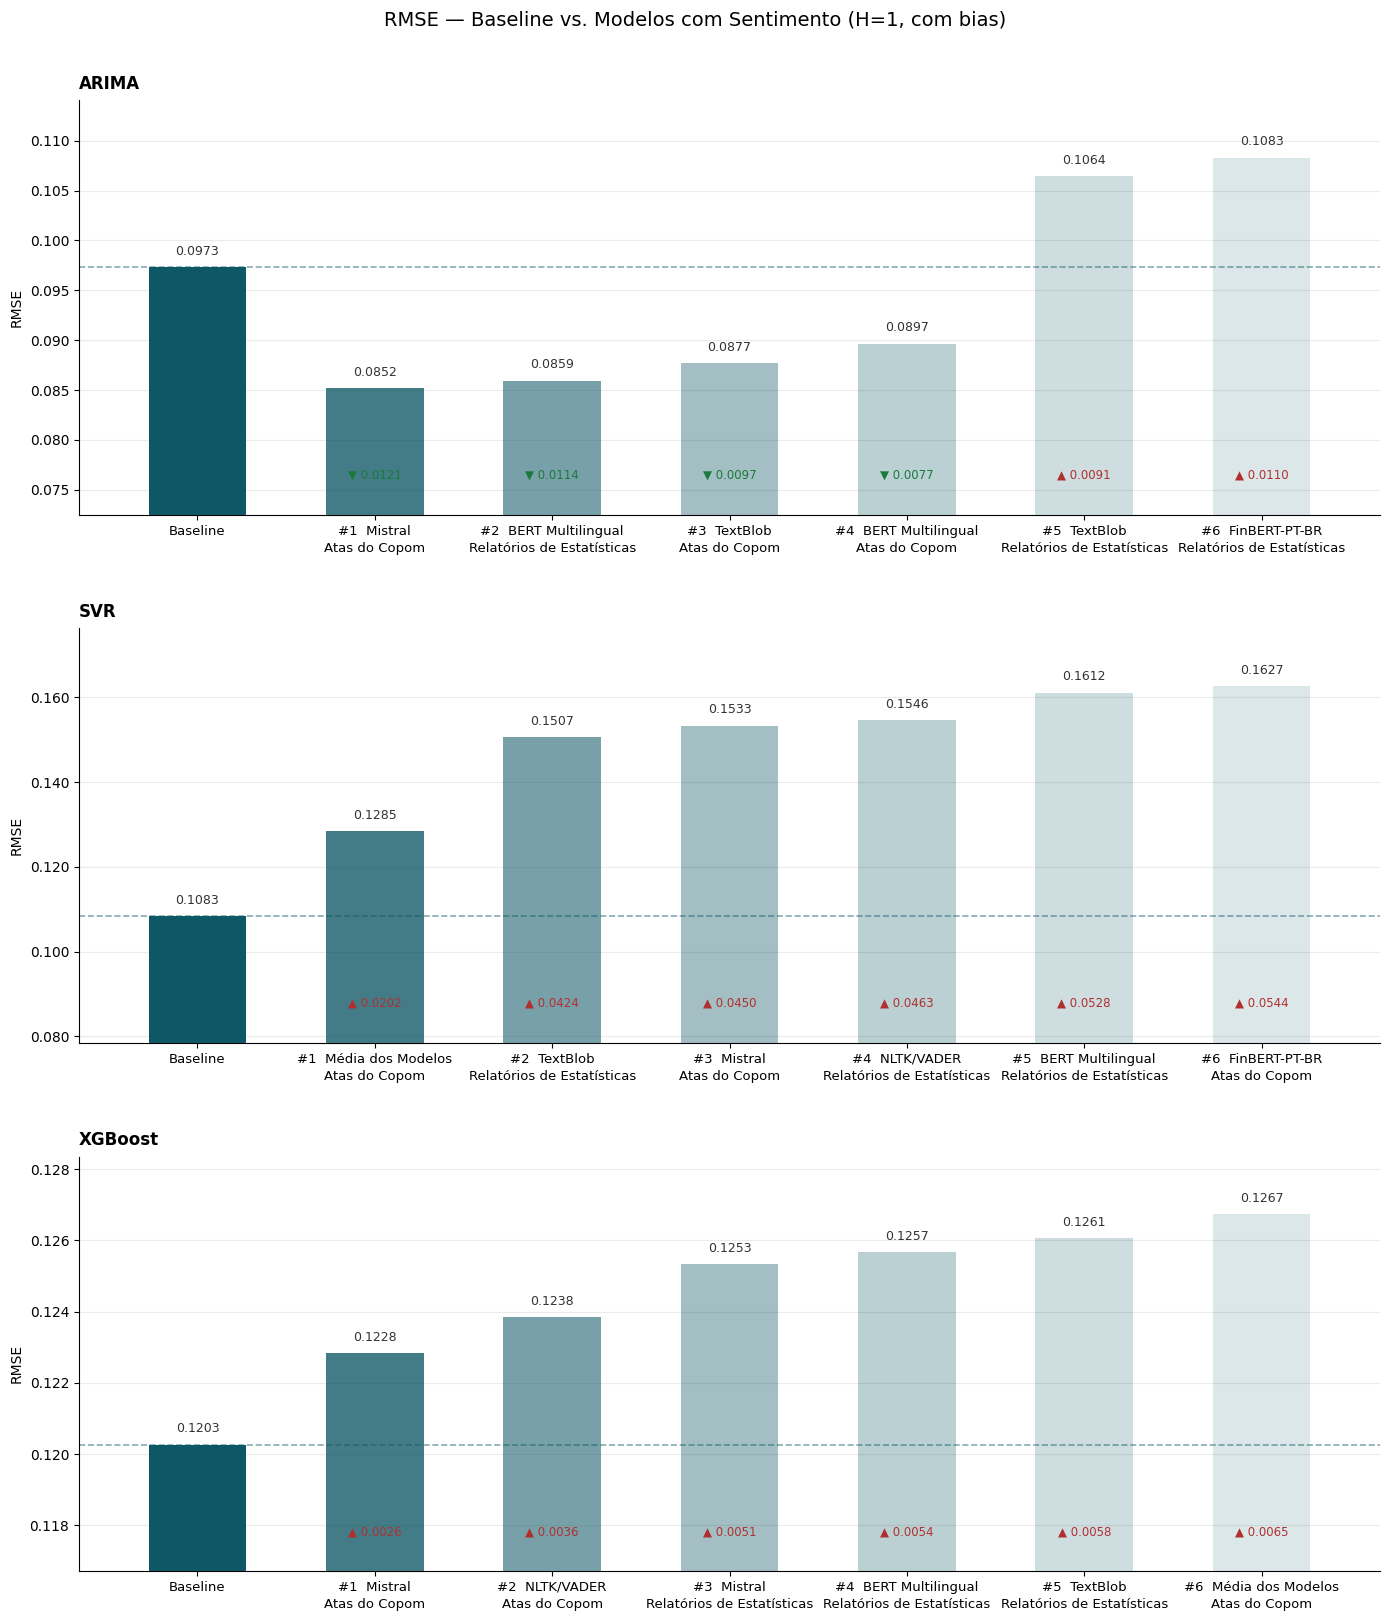

In [14]:
familias = ["ARIMA", "SVR", "XGBoost"]
_familia_sent = {"ARIMA": "ARIMAX", "SVR": "SVR", "XGBoost": "XGBoost"}
ALPHA_SENT = [0.78, 0.56, 0.38, 0.28, 0.20, 0.14]

# Um gráfico por família, empilhados verticalmente
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle("RMSE — Baseline vs. Modelos com Sentimento (H=1, com bias)", fontsize=14, y=1.01)

for ax, familia in zip(axes, familias):
    rmse_base   = rmse_baseline.get(familia, np.nan)
    familia_sent = _familia_sent.get(familia, familia)
    top3_f = (
        sent_cb[sent_cb["Família"] == familia_sent]
        .sort_values("RMSE")
        .reset_index(drop=True)
    )

    labels = ["Baseline"]
    rmses  = [rmse_base]
    for _, row in top3_f.iterrows():
        labels.append(
            f"#{int(row['Rank'])}  {row['Modelo Sentimento']}\n"
            f"{row['Tipo Relatório']}"
        )
        rmses.append(row["RMSE"])

    n      = len(rmses)
    x      = np.arange(n)
    alphas = [1.0] + ALPHA_SENT[:n - 1]

    bars = ax.bar(x, rmses, color=COLOR, width=0.55, zorder=3)
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)

    # valor acima de cada barra
    y_range = max(rmses) - min(rmses) if len(rmses) > 1 else rmses[0] * 0.05
    for bar, v in zip(bars, rmses):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + y_range * 0.04,
            f"{v:.4f}", ha="center", va="bottom", fontsize=9, color="#333333",
        )

    # linha de referência baseline
    ax.axhline(rmse_base, color=COLOR, linestyle="--", lw=1.2, alpha=0.5, zorder=2)

    # delta no rodapé
    y_delta = min(rmses) - y_range * 0.35
    for bar, v in zip(bars[1:], rmses[1:]):
        delta = v - rmse_base
        cor   = "#1a7a3c" if delta < 0 else "#b03030"
        sinal = "▼" if delta < 0 else "▲"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_delta,
            f"{sinal} {abs(delta):.4f}",
            ha="center", va="top", fontsize=8.5, color=cor, zorder=4,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9.5, ha="center", linespacing=1.4)
    ax.set_title(familia, fontsize=12, fontweight="bold", loc="left", pad=8)
    ax.set_ylabel("RMSE", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.grid(axis="y", alpha=0.25, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.06)
    ax.set_ylim(
        min(rmses) - y_range * 0.55,
        max(rmses) + y_range * 0.25,
    )

plt.tight_layout(h_pad=3.5)
plt.savefig("rmse_comparativo_nb07.png", dpi=150, bbox_inches="tight")
plt.show()